### Overview

When working with optical satellite imagery, we need to ensure the cloudy-pixels are removed from analysis. Most providers supply QA bands detailing locations of cloudy pixels. There are also third-party cloud-masking packages that can be used to locate and mask cloudy pixels.

In this section, we will use the Scene Classification (SCL) band supplied with Sentinel-2 Level-2A images to remove clouds and cloud-shadows from a scene.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

print(f'Environment: {environment}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
        jupyter-server-proxy odc-algo

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pystac_client
import rioxarray as rxr
import xarray as xr
from matplotlib.colors import ListedColormap
from odc.stac import configure_s3_access, load

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Get a Sentinel-2 Scene

We define a location and time of interest to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608
year = 2023

Search the catalog for matching items. This time we use `'direction': 'desc'` in the `sortby` parameter to get results where the first scene has the highest cloud-cover.

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={
        'eo:cloud_cover': {'lt': 50},
        's2:nodata_pixel_percentage': {'lt': 10}},
    sortby=[
        {'field': 'properties.eo:cloud_cover',
         'direction': 'desc'}
        ]
)
items = search.item_collection()

# Items were sorted in descending order of cloud cover,
# so the first item is the most cloudy
most_cloudy = items[0]

ds = load(
    [most_cloudy],
    bands=['red', 'green', 'blue', 'scl'],
    resolution=100, # Load the data at lower resolution to speed up processing 
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)

scene = ds.squeeze()
# Mask nodata values
scene = scene.where(scene != 0)

# Apply scale/offset
scale = 0.0001
offset = -0.1
# Select spectral bands (all except 'scl')
data_bands = [band for band in scene.data_vars if band != 'scl']
for band in data_bands:
  scene[band] = scene[band] * scale + offset

Let's call `compute()` to kick-off the dask graph. Dask will query the cloud-hosted dataset to fetch the required pixels. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [ ]:
%%time
scene = scene.compute()

### Visualize the Scene

To visualize our Dataset, we first convert it to a DataArray using the `to_array()` method. All the variables will be converted to a new dimension. Since our variables are image bands, we give the name of the new dimesion as band.


In [ ]:
scene_da = scene.to_array('band')

The clouds will have a much higher reflectance, so `robust=True` will not give us appropriate visualization. We supply hardcoded min/max values as 0 and 0.3 which is the normal range of reflectance values of earth targets.

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
scene_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=0, vmax=0.3)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Create a Cloud Mask

The Scene Classification (SCL) band has each pixel classified into one of the following classes.

| Value | Description                                 |
|-------|---------------------------------------------|
| 0     | No Data                                     |
| 1     | Saturated or defective pixel                |
| 2     | Dark area pixels                            |
| 3     | Cloud shadows                               |
| 4     | Vegetation                                  |
| 5     | Not vegetated                               |
| 6     | Water                                       |
| 7     | Clouds Low Probability / Unclassified                                |
| 8     | Cloud medium probability                    |
| 9     | Cloud high probability                      |
| 10    | Thin cirrus                                 |
| 11    | Snow / Ice                                  |

We select the types of pixels we want to mask. Let's create a mask that will remove all pixels marked `Cloud shadows (3)`, `Cloud Medium Probability (8)`, `Cloud High Probability (9)` and `Thin Cirrus (10)`.

In [ ]:
mask = scene['scl'].isin([3,8,9,10])

Visualize the mask by overlaying it on the scene.

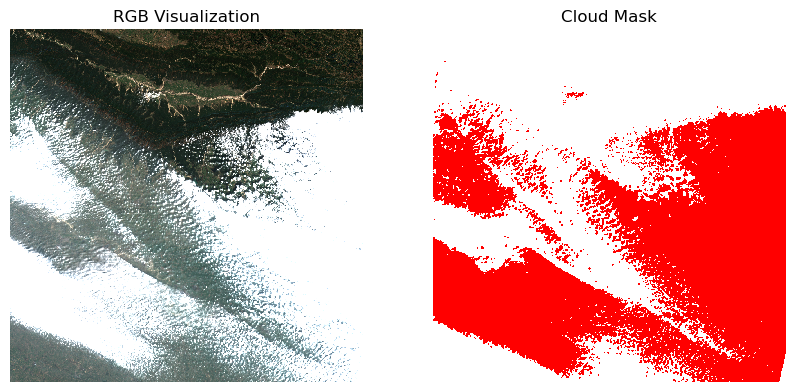

In [22]:
fig, (ax0, ax1) = plt.subplots(1, 2)
fig.set_size_inches(10,5)
scene_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax0,
    vmin=0, vmax=0.3)
ax0.set_title('RGB Visualization')

# RGBA: Transparent, Red
mask_colormap = ListedColormap(['#00000000', '#FF0000FF'])
mask.plot.imshow(
    ax=ax1,
    cmap=mask_colormap,
    add_colorbar=False)

ax1.set_title('Cloud Mask')
for ax in (ax0, ax1):
  ax.set_axis_off()
  ax.set_aspect('equal')
plt.show()

Once we are satisfied that the mask looks good, we go ahead and apply the mask on the scene.

In [ ]:
# Apply the mask to all the data bands
scene_masked = scene[data_bands].where(~mask)
scene_masked

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [ ]:
#client.shutdown()

### Exercise

The [`odc-algo`](https://github.com/opendatacube/odc-algo/tree/main) package provides useful algorithms for remote sensing data processing. We will use the `mask_cleanup()` function to apply morphological operators to clean up the cloud mask for more robust cloud masking. 

It supports the following operations

* `closing`: Removes small holes in cloud - morphological closing
* `opening`: Shrinks away small areas of the mask
* `dilation`: Adds padding to the mask
* `erosion`: Shrinks the mask

Along with the operation, you specify a `radius` parameter that controls the size of the window when applying the operations. 

The code snippet below shows how to use the function. Test these operations to see its effect on the mask. Visualize the `mask` and `cleaned_mask` side-by-side to see the results.

In [ ]:
from odc.algo import mask_cleanup

# Contract and then expand the cloud mask to remove small areas
cleaned_mask = mask_cleanup(mask, [('opening', 2), ('dilation', 3)])